In [372]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [373]:
# Load dataframe
df = pd.read_csv('my_features_a5_ss.csv')
df.head()

,query_id,query_contents,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,...,cls_760,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,Best Alpha,MRR
0,1048585,what is paula deen's brother,6,2,4,0.333333,0.666667,1,0,0,...,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,0.00,0.500000
1,2,Androgen receptor define,3,0,3,0.000000,1.000000,0,0,0,...,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,0.00,0.500000
2,524332,treating tension headaches without medication,5,0,5,0.000000,1.000000,0,0,0,...,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,0.00,0.142857
3,1048642,what is paranoid sc,4,2,2,0.500000,0.500000,1,0,0,...,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,0.02,0.020833
4,524447,treatment of varicose veins in legs,6,2,4,0.333333,0.666667,0,0,0,...,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,0.71,0.029412


In [374]:
# all ids in df are unique
print(df["query_id"].nunique())

6980


In [375]:
print(df.shape)
print(np.mean(df["MRR"]))

(6980, 783)
0.46135258835763143


In [376]:
buckets_train = []

for i in range(df.shape[0]):
    if df.iloc[i, 782] >= 0.9:
        buckets_train.append(9)
    elif df.iloc[i, 782] >= 0.8:
        buckets_train.append(8)
    elif df.iloc[i, 782] >= 0.7:
        buckets_train.append(7)
    elif df.iloc[i, 782] >= 0.6:
        buckets_train.append(6)
    elif df.iloc[i, 782] >= 0.5:
        buckets_train.append(5)
    elif df.iloc[i, 782] >= 0.4:
        buckets_train.append(4)
    elif df.iloc[i, 782] >= 0.3:
        buckets_train.append(3)
    elif df.iloc[i, 782] >= 0.2:
        buckets_train.append(2)
    elif df.iloc[i, 782] >= 0.1:
        buckets_train.append(1)
    else:
        buckets_train.append(0)

df["alpha_buckets"] = buckets_train

In [377]:
feature_cols = [col for col in df.columns if col.startswith('cls_')] + [
    'stopword_count', 'nonstopword_count',
    'stopword_density', 'nonstopword_density',
    'query_length', 'what', 'where', 'when'
]

target_cols = ['query_id', 'alpha_buckets']

# X and y dataframes
X = df[feature_cols]
y = df[target_cols]

X.head()

,cls_0,cls_1,cls_2,cls_3,cls_4,cls_5,cls_6,cls_7,cls_8,cls_9,...,cls_766,cls_767,stopword_count,nonstopword_count,stopword_density,nonstopword_density,query_length,what,where,when
0,-0.062403,0.027169,0.270110,0.207758,-0.060775,0.176636,-0.010139,-0.335960,0.075902,-0.534105,...,0.285646,0.290846,2,4,0.333333,0.666667,6,1,0,0
1,-0.093802,0.026285,0.276022,0.158549,0.240934,0.205888,0.180795,-0.169981,-0.014223,-0.287796,...,0.649183,-0.100653,0,3,0.000000,1.000000,3,0,0,0
2,-0.123280,-0.080808,0.291058,0.446603,-0.006283,-0.004077,0.116068,-0.064539,-0.030202,-0.194538,...,0.435811,-0.153385,0,5,0.000000,1.000000,5,0,0,0
3,-0.097564,0.200338,0.162613,0.269157,-0.548503,0.090923,0.157506,-0.074866,-0.481509,-0.719581,...,0.020971,-0.071258,2,2,0.500000,0.500000,4,1,0,0
4,0.013936,-0.089972,0.497938,0.602115,-0.045929,-0.195976,0.119508,0.158035,-0.314570,-0.288453,...,0.727291,-0.124383,2,4,0.333333,0.666667,6,0,0,0


In [378]:
print(y)

      query_id  alpha_buckets
0      1048585              5
1            2              5
2       524332              1
3      1048642              0
4       524447              0
...        ...            ...
6975    734979              5
6976    524166              3
6977    968921              3
6978    786375              3
6979   1048565              2

[6980 rows x 2 columns]


In [379]:
print(X.shape)

(6980, 776)


In [380]:
# buckets = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
bucket_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# y_bucketed = np.digitize(y, buckets)
# y_bucketed = y_bucketed - 1

In [381]:
# print(y_bucketed)

In [382]:
# print(len(y_bucketed))

In [383]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [384]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [385]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=0.01,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [386]:
print(y_train)

      query_id  alpha_buckets
6610    249792              0
6565    510152              2
4003    930293              1
1010   1098057              9
4617    436586              2
...        ...            ...
3772    131768              2
5191    988294              1
5226    995029              9
5390    993748              9
860     398335              0

[5584 rows x 2 columns]


In [387]:
# Train/fit model
mlp.fit(X_train, y_train['alpha_buckets'])

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 1.90285456
Iteration 2, loss = 1.58790284
Iteration 3, loss = 1.42129601
Iteration 4, loss = 1.27769952
Iteration 5, loss = 1.11730454
Iteration 6, loss = 0.95646145
Iteration 7, loss = 0.79853117
Iteration 8, loss = 0.66273980
Iteration 9, loss = 0.53699645
Iteration 10, loss = 0.43464199
Iteration 11, loss = 0.33748108
Iteration 12, loss = 0.25949942
Iteration 13, loss = 0.20009881
Iteration 14, loss = 0.15666776
Iteration 15, loss = 0.12640223
Iteration 16, loss = 0.10089423
Iteration 17, loss = 0.08347401
Iteration 18, loss = 0.06952036
Iteration 19, loss = 0.06316403
Iteration 20, loss = 0.05794601
Iteration 21, loss = 0.05224466
Iteration 22, loss = 0.04820448
Iteration 23, loss = 0.04411638
Iteration 24, loss = 0.04328607
Iteration 25, loss = 0.04103215
Iteration 26, loss = 0.03718152
Iteration 27, loss = 0.03420208
Iteration 28, loss = 0.03528242
Iteration 29, loss = 0.03802704
Iteration 30, loss = 0.03605080
Iteration 31, loss = 0.03429403
Iteration 32, los

In [388]:
print(y_pred)

[9 9 9 ... 3 9 9]


Accuracy: 0.1956

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.15      0.16       220
           1       0.12      0.10      0.11       164
           2       0.17      0.16      0.16       216
           3       0.16      0.15      0.15       182
           5       0.18      0.20      0.19       235
           9       0.27      0.31      0.29       379

    accuracy                           0.20      1396
   macro avg       0.18      0.18      0.18      1396
weighted avg       0.19      0.20      0.19      1396


Confusion Matrix:
[[ 33  20  29  30  45  63]
 [ 31  16  20  16  31  50]
 [ 28  21  34  26  42  65]
 [ 24  14  27  27  38  52]
 [ 33  26  31  22  47  76]
 [ 50  37  60  53  63 116]]


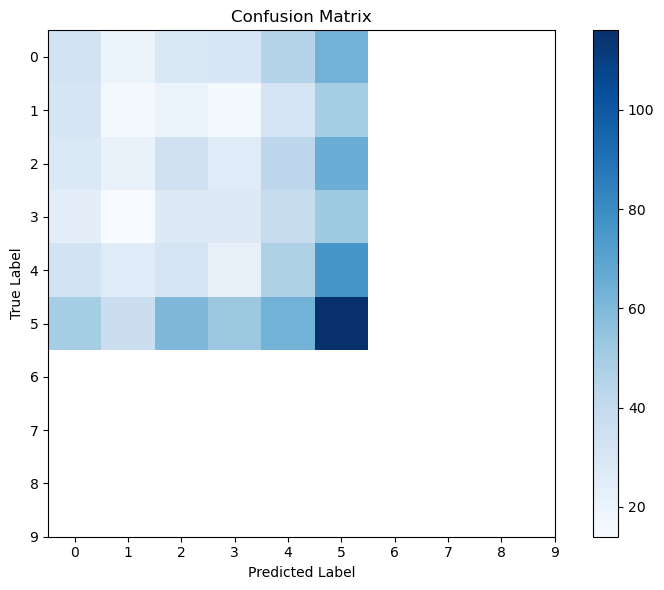

In [389]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate performance
accuracy = accuracy_score(y_test['alpha_buckets'], y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test['alpha_buckets'], y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test['alpha_buckets'], y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, bucket_labels)
plt.yticks(tick_marks, bucket_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [390]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test['alpha_buckets'], y_pred)
rmse = mean_squared_error(y_test['alpha_buckets'], y_pred, squared=False)
mae = mean_absolute_error(y_test['alpha_buckets'], y_pred)
r2 = r2_score(y_test['alpha_buckets'], y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 22.6275
RMSE: 4.7568
MAE: 3.7335
R²: -1.0072


In [391]:
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train['alpha_buckets'], y_pred_train)
mse_test = mean_squared_error(y_test['alpha_buckets'], y_pred_test)
r2_train = r2_score(y_train['alpha_buckets'], y_pred_train)
r2_test = r2_score(y_test['alpha_buckets'], y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0000, Test MSE: 22.6275
Train R2: 1.0000, Test R2: -1.0072


In [392]:
feature_cols = [col for col in df.columns if col.startswith('cls_')] + [
    'stopword_count', 'nonstopword_count',
    'stopword_density', 'nonstopword_density',
    'query_length', 'what', 'where', 'when'
]
new_X = df[feature_cols]

y_new_pred = mlp.predict(new_X)
print(y_new_pred)

df['predicted_value'] = y_new_pred 

df.to_csv("predicted_output.csv", index=False)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


[0 9 9 ... 0 9 9]


In [393]:
print(y_pred)

[9 9 9 ... 3 9 9]


In [394]:
alpha_map = {
    '0': 0,
    '1': 0.1,
    '2': 0.2,
    '3': 0.3,
    '4': 0.4,
    '5': 0.5,
    '6': 0.6,
    '7': 0.7,
    '8': 0.8,
    '9': 0.9,
}

y_pred_list = [str(x) for x in y_pred.tolist()]

for i in range(len(y_pred_list)):
    y_pred_list[i] = alpha_map[y_pred_list[i]]

print(y_pred_list)

[0.9, 0.9, 0.9, 0.3, 0.9, 0.1, 0.2, 0, 0.1, 0.2, 0.9, 0.9, 0.9, 0.2, 0.9, 0.1, 0.9, 0.9, 0.5, 0, 0.9, 0, 0.5, 0.9, 0.9, 0.3, 0.5, 0.5, 0.9, 0.5, 0.9, 0.9, 0, 0.9, 0.3, 0.9, 0.9, 0.9, 0.1, 0.3, 0.9, 0.9, 0.3, 0.1, 0.1, 0.9, 0.2, 0.3, 0.2, 0.9, 0.9, 0.2, 0, 0.2, 0.3, 0.2, 0.9, 0.9, 0.5, 0.5, 0.2, 0.1, 0.9, 0.5, 0.5, 0.1, 0, 0.2, 0, 0.2, 0.5, 0, 0.1, 0.9, 0.2, 0.9, 0.9, 0.9, 0.5, 0.9, 0.2, 0.3, 0.1, 0.9, 0.5, 0.9, 0.3, 0.2, 0, 0.3, 0, 0.5, 0.3, 0, 0, 0.9, 0.9, 0, 0.9, 0, 0.1, 0.9, 0, 0.9, 0.2, 0.5, 0.5, 0.1, 0.9, 0.2, 0.5, 0.2, 0.5, 0.9, 0.2, 0.3, 0.3, 0.9, 0.1, 0.3, 0.5, 0.2, 0.9, 0.2, 0.2, 0, 0.9, 0.5, 0, 0.2, 0.2, 0.9, 0.2, 0.2, 0.9, 0.5, 0.2, 0.3, 0.3, 0.1, 0, 0.5, 0.9, 0.3, 0.9, 0.9, 0, 0.1, 0.3, 0.9, 0.9, 0.9, 0.3, 0.9, 0.2, 0.1, 0.2, 0.5, 0.1, 0.2, 0.5, 0, 0.2, 0.3, 0.5, 0, 0.5, 0, 0.9, 0.9, 0.5, 0, 0, 0.5, 0.2, 0.9, 0.5, 0.1, 0, 0.9, 0.3, 0.5, 0.9, 0.5, 0, 0.2, 0, 0.1, 0.3, 0.5, 0, 0.3, 0.2, 0, 0.9, 0.1, 0.1, 0.5, 0.5, 0.9, 0.1, 0.9, 0.9, 0.2, 0.5, 0.9, 0.5, 0.9, 0.9, 0.5, 0.3, 0.

In [395]:
qrels_df = pd.read_csv("qrels.dev.tsv", sep="\t", names=['Query ID', '0', 'Document ID', "Relevance"])
qrels_df = qrels_df.drop(columns=['0'])
qrels_df.head()

,Query ID,Document ID,Relevance
0,1102432,2026790,1
1,1102431,7066866,1
2,1102431,7066867,1
3,1090282,7066900,1
4,39449,7066905,1


In [396]:
print(qrels_df.shape)

(59273, 3)


In [397]:
print(df["query_id"])
print(len(y_pred))

data = {'Query ID': y_test["query_id"],
        'Alpha Values': y_pred}

results_df = pd.DataFrame(data)
print(results_df)

0       1048585
1             2
2        524332
3       1048642
4        524447
         ...   
6975     734979
6976     524166
6977     968921
6978     786375
6979    1048565
Name: query_id, Length: 6980, dtype: int64
1396
      Query ID  Alpha Values
4119    148761             9
3477    638928             9
4322    267187             9
3349    632055             3
469    1064473             9
...        ...           ...
1897   1095495             0
1032   1083535             2
4480    167204             3
3866    661398             9
1880    570979             9

[1396 rows x 2 columns]


In [398]:
splade_df = pd.read_csv("splade-dev.trec", sep="\t", names=['Query ID', 'Q0', 'Document ID', 'Rank', 'Score', 'R0'])
splade_df = splade_df.drop(splade_df.columns[[1,5]], axis=1)

dense_df = pd.read_csv("splade_llama_rerank.tsv", sep="\t", names=['Query ID', 'Document ID', 'Score'])

In [399]:
print(splade_df[splade_df["Query ID"] == 148761])
print(splade_df)

         Query ID  Document ID  Rank  Score
4119000    148761      7495325     0  75753
4119001    148761      7495323     1  73955
4119002    148761      7030056     2  72652
4119003    148761      7495324     3  72361
4119004    148761      7495320     4  71304
...           ...          ...   ...    ...
4119995    148761      2918872   995  41228
4119996    148761      5128952   996  41226
4119997    148761      3931295   997  41225
4119998    148761       724566   998  41210
4119999    148761      4152580   999  41203

[1000 rows x 4 columns]
         Query ID  Document ID  Rank   Score
0         1048585      7187155     0  104472
1         1048585      7187160     1  100811
2         1048585      7187157     2   99206
3         1048585      7187158     3   98698
4         1048585      3100835     4   86255
...           ...          ...   ...     ...
6979995   1048565      4838288   995   66246
6979996   1048565      2133477   996   66245
6979997   1048565      5753707   997   662

In [400]:
def best_weights_fixed(dense_df, sparse_df, query_id, alpha):
    # Initialize best MRR value
    best_mrr = 0

    # Filter by query ID
    filtered_dense_df = dense_df[dense_df["Query ID"] == query_id].copy()
    filtered_sparse_df = sparse_df[sparse_df["Query ID"] == query_id].copy()

    # Find weighted scores
    filtered_dense_df["Score"] *= (1 - alpha)
    filtered_sparse_df["Score"] *= alpha

    # Merge rankings
    merged = filtered_dense_df.merge(filtered_sparse_df, on="Document ID", how="outer", suffixes=("_dense", "_sparse")).fillna(0)
    merged["Final Score"] = merged["Score_dense"] + merged["Score_sparse"]

    # Rank documents
    ranked_results = merged.sort_values("Final Score", ascending=False)
    ranked_docs = ranked_results["Document ID"].tolist()[:10]

    # MRR
    relevant_docs = qrels_df[qrels_df["Query ID"] == query_id]["Document ID"]

    rank = len(ranked_docs) + 1
    for doc in relevant_docs:    
        if doc in ranked_docs:
            current_rank = ranked_docs.index(doc) + 1
            if current_rank < rank:
                rank = current_rank

    if rank > 10:
        mrr_score = 0
    else:
        mrr_score = 1 / rank

    return alpha, mrr_score


In [401]:
print(y_test["query_id"].to_list())

[148761, 638928, 267187, 632055, 1064473, 1066792, 512685, 744891, 1083743, 1086271, 247194, 510858, 199776, 1012431, 34039, 970605, 694561, 523062, 1094825, 1095557, 114633, 393954, 1096887, 1095335, 270642, 1083125, 998658, 884878, 65770, 56993, 70852, 571696, 1085862, 1097153, 1057270, 478295, 1014132, 583325, 1002197, 263670, 1092863, 662436, 1072479, 884533, 527625, 1090839, 266760, 156251, 1066971, 1056159, 544123, 37685, 76770, 990307, 1095749, 1022630, 161224, 432602, 975495, 1098570, 1092416, 1088475, 418552, 1083430, 1011618, 597870, 1091654, 1096087, 788484, 635125, 466202, 1087122, 1056950, 1084712, 1089043, 662282, 1088845, 244821, 714709, 605467, 1084516, 891498, 1002252, 855546, 881582, 679658, 458235, 1091529, 914406, 1038592, 783781, 1095807, 679167, 1100134, 1007696, 1002584, 944451, 1098222, 549731, 1084602, 1083909, 1054707, 809933, 81993, 1083267, 875787, 1006000, 375291, 21948, 1014242, 926700, 1087603, 684459, 1084273, 1062223, 392195, 1086305, 1096425, 705681, 8

In [402]:
alphas = []
mrrs = []

df_loaded = pd.read_csv("predicted_output.csv")
y_test_list = y_test["query_id"].to_list()

for idx, query in enumerate(y_test_list):
    # print(query)
    predicted_alpha = y_pred_list[idx]
    # print(predicted_alpha)
    # print(type(query))
    alpha, mrr = best_weights_fixed(dense_df, splade_df, query, predicted_alpha)
    alphas.append(alpha)
    mrrs.append(mrr)
    # if query % 100 == 0:
    #     print(query)

In [403]:
# MRR calculations
avg_mrr = sum(mrrs) / len(mrrs)
print(f"Avg MRRs: {avg_mrr}")

Avg MRRs: 0.3792985627871014
